In [1]:
%pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [3]:
df=pd.read_csv('vgsales.csv')
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Read the first ten rows of data to get a preliminary understanding of the variable structure and contents.

In [4]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


Observe the structure and check for missing values.

The dataset has 16,598 rows. Rank, Name, Platform, Genre, NA_Sales, EU_Sales, JP_Sales, Other_Sales, and Global_Sales have no missing values.

Year has 271 missing values, and Publisher has 58 missing values.

The Dtype of Year is not ideal and should be converted from float to int. 

In [5]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

A more precise missing value check confirms the same results as above.

In [6]:
df['Name']=df['Name'].str.strip()
df['Platform']=df['Platform'].str.strip()
df['Genre']=df['Genre'].str.strip()
df['Publisher']=df['Publisher'].str.strip()

df.head(10)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Remove unnecessary spaces to prevent data errors and keep the case distinction, which is helpful for later visualizations. 

In [7]:
df_new = df.dropna(subset=['Year', 'Publisher']).copy()
df_new['Year'] = df_new['Year'].astype(int)
df_new.info()

<class 'pandas.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  str    
 2   Platform      16291 non-null  str    
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  str    
 5   Publisher     16291 non-null  str    
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 1.5 MB


Since missing values in Year and Publisher cannot be replaced by mean or mode without causing data distortion, the missing values for Year and Publisher are removed.

Also, convert Year's Dtype to int.

Check again after these operations.

In [8]:
df_new.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Data overview: There are extreme values in the Global_Sales column. 
The mean is 0.54, but the maximum is 82.74. In the video game industry, this extreme value is not a data error, so it is retained. 

In [9]:
df_new.duplicated().sum()

np.int64(0)

A duplicate check was performed, and the output indicates that there are no duplicate rows.

1. Overview of Categorical Variables

In [10]:
df_new.describe(include='object')

/var/folders/1x/gxw5bvrj7fxdhhgb292y_9gh0000gn/T/ipykernel_34595/2397103418.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_new.describe(include='object')


,Name,Platform,Genre,Publisher
count,16291,16291,16291,16291
unique,11325,31,12,576
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2131,3251,1339


From the output above, the dataset contains 31 gaming platforms, 12 game genres, and 576 publishers. 
Among them, the DS platform released the most games, Action games are the most popular, 
and Electronic Arts published the most games.

In [11]:
df_new['Platform'].value_counts().head(10)

Platform
DS      2131
PS2     2127
PS3     1304
Wii     1290
X360    1234
PSP     1197
PS      1189
PC       938
XB       803
GBA      786
Name: count, dtype: int64

The details under the Platform variable help understand the major gaming platforms.  

In [12]:
df_new['Genre'].value_counts()

Genre
Action          3251
Sports          2304
Misc            1686
Role-Playing    1470
Shooter         1282
Adventure       1274
Racing          1225
Platform         875
Simulation       848
Fighting         836
Strategy         670
Puzzle           570
Name: count, dtype: int64

The details under the Genre variable help understand the most popular game types.  

In [13]:
df_new['Publisher'].value_counts().head(10)

Publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
THQ                              712
Nintendo                         696
Sony Computer Entertainment      682
Sega                             632
Take-Two Interactive             412
Name: count, dtype: int64

The details under the Publisher variable help understand the main game publishers.

2. Overview of Numerical Variables

In [14]:
print(f"Mean: {df_new['Global_Sales'].mean():.2f}")  
print(f"Median: {df_new['Global_Sales'].median():.2f}")  

Mean: 0.54
Median: 0.17


Because mean > median and the gap is large, the distribution is right-skewed, indicating that a few high-selling games pull the average up.  

In [15]:
df_new['Global_Sales'].describe()

count    16291.000000
mean         0.540910
std          1.567345
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         82.740000
Name: Global_Sales, dtype: float64

The output above shows the approximate distribution of global sales, with most games in the low-sales range and a few games having extremely high sales.  

In [16]:
df_new.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

Genre
Action          1722.84
Sports          1309.24
Shooter         1026.20
Role-Playing     923.83
Platform         829.13
Misc             789.87
Racing           726.76
Fighting         444.05
Simulation       389.98
Puzzle           242.21
Adventure        234.59
Strategy         173.27
Name: Global_Sales, dtype: float64

The output above displays the game genres with the highest sales.

In [17]:
df_new[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000000,0.768923,0.451283,0.634518,0.941269
EU_Sales,0.768923,1.000000,0.436379,0.726256,0.903264
JP_Sales,0.451283,0.436379,1.000000,0.290559,0.612774
Other_Sales,0.634518,0.726256,0.290559,1.000000,0.747964
Global_Sales,0.941269,0.903264,0.612774,0.747964,1.000000


The output above shows the correlation between sales in different regions and global sales.  

In [18]:
df_new.groupby('Year')['Global_Sales'].sum()

Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    414.01
2005    458.51
2006    521.04
2007    609.92
2008    678.90
2009    667.30
2010    600.29
2011    515.80
2012    363.49
2013    368.11
2014    337.03
2015    264.44
2016     70.90
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64

The output above demonstrates how game sales change over time.

Chart 1:

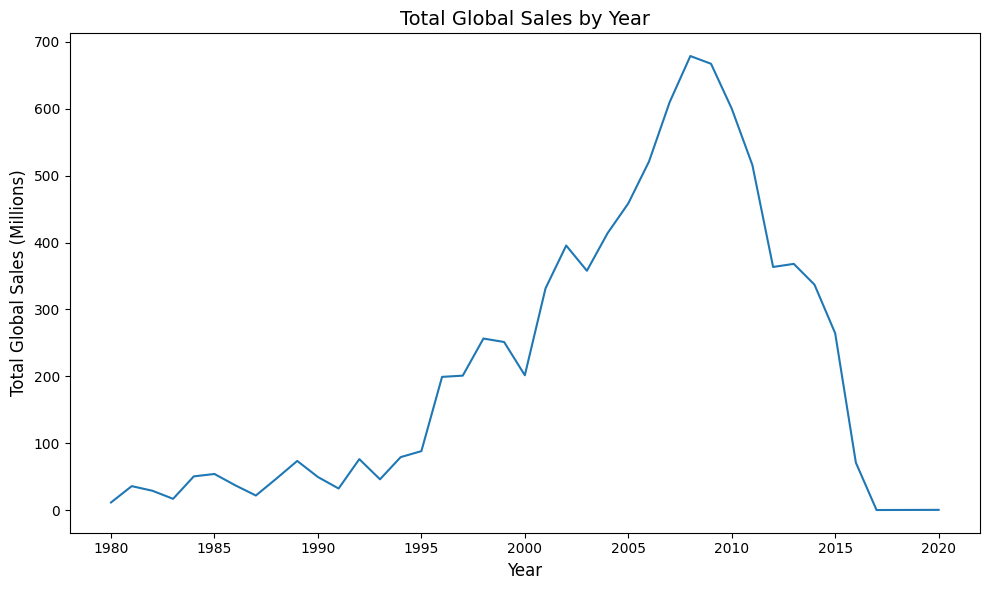

In [19]:
year_sales = df_new.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(10, 6))
plt.plot(year_sales.index, year_sales.values)

plt.title('Total Global Sales by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Global Sales (Millions)', fontsize=12)

plt.tight_layout()
plt.show()

This line chart shows the relationship between global game sales and release year. 

The chart indicates that game sales increased rapidly each year from 1995 to 2010, 
reaching the peak around 2010, and then began to decline. 


Chart2:

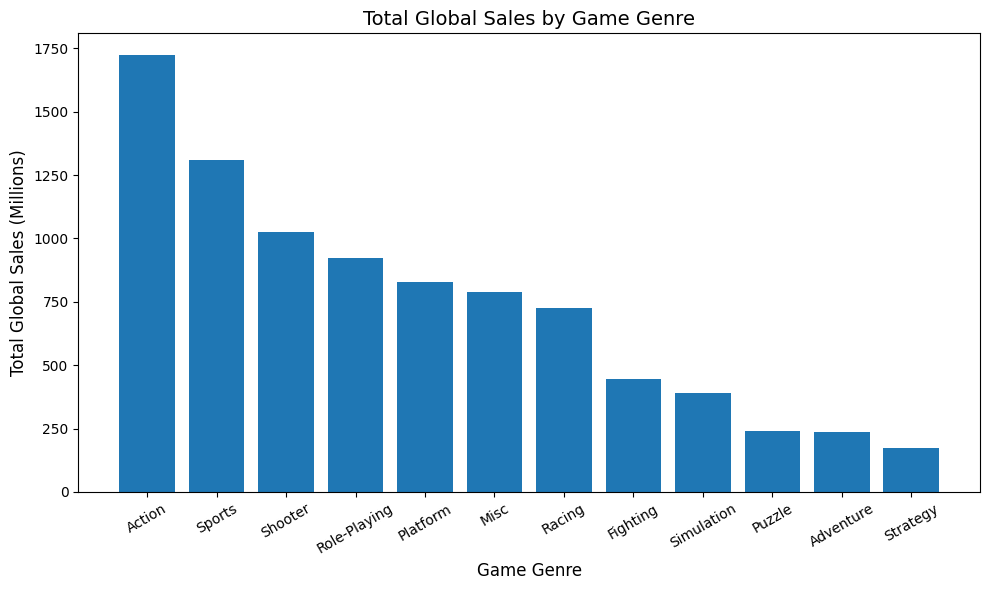

In [20]:
#Adapted from Week 4 lab example
genre_sales = df_new.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(genre_sales.index, genre_sales.values)
plt.title('Total Global Sales by Game Genre', fontsize=14)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Total Global Sales (Millions)', fontsize=12)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

The bar chart above first categorizes global sales by game genre. 
Since there are many genres, the x-axis labels are rotated for easier readability.  

This bar chart displays the global sales for different game genres. 
It is clear that Action games are the most popular and highest-selling, 
followed by Sports and Shooter genres.  

Chart3:

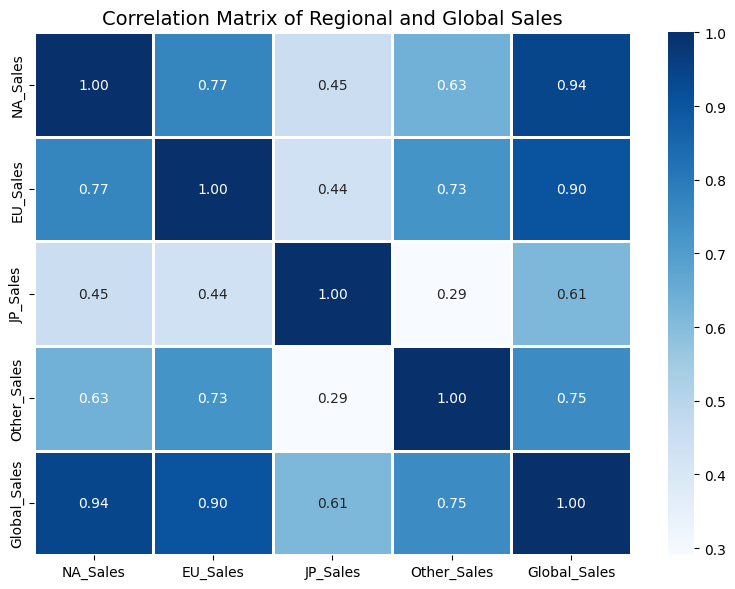

In [21]:
plt.figure(figsize=(8, 6))
corr_matrix = df_new[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()
plt.title('Correlation Matrix of Regional and Global Sales', fontsize=14)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=1
)
plt.tight_layout()
plt.show()

The heatmap above shows the correlation between regional sales and global sales, 
using different shades of blue to represent different intensities. 
To make it easier for colorblind readers and improve readability, 
the actual correlation values are displayed in each cell, 
and spacing is maintained between cells to avoid similar colors blending together.  

From the heatmap we can observe:
- Sales in North America and Europe are strongly correlated with global sales, with North America having the highest correlation.  
- North American sales and European sales are strongly correlated, indicating the two markets perform similarly.  
- Sales in North America and Europe are positively correlated with Japanese sales, but there are some differences.

Chart4:

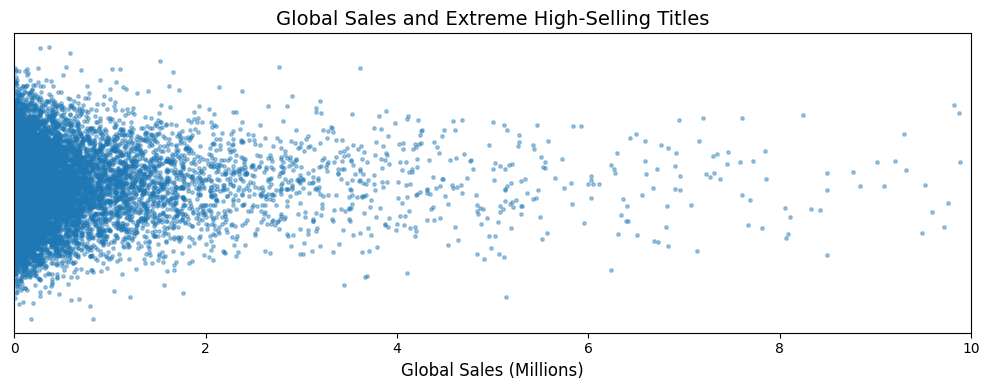

In [22]:
plt.figure(figsize=(10, 4))

x = df_new['Global_Sales']
y = np.random.normal(loc=0, scale=0.04, size=len(df_new))

plt.scatter(x, y, alpha=0.4, s=6)

plt.xlim(0, 10)
plt.yticks([])
plt.title('Global Sales and Extreme High-Selling Titles', fontsize=14)
plt.xlabel('Global Sales (Millions)', fontsize=12)

plt.tight_layout()
plt.show()

This scatter plot shows the sales of individual games, with each point representing one game. 
From the chart, it can be seen that a small number of top-ranked games have very high sales, representing blockbuster titles, 
while the majority of games have relatively low sales. 
A long-tail effect is present, where a few blockbuster games account for most of the total sales.  

Chart5:

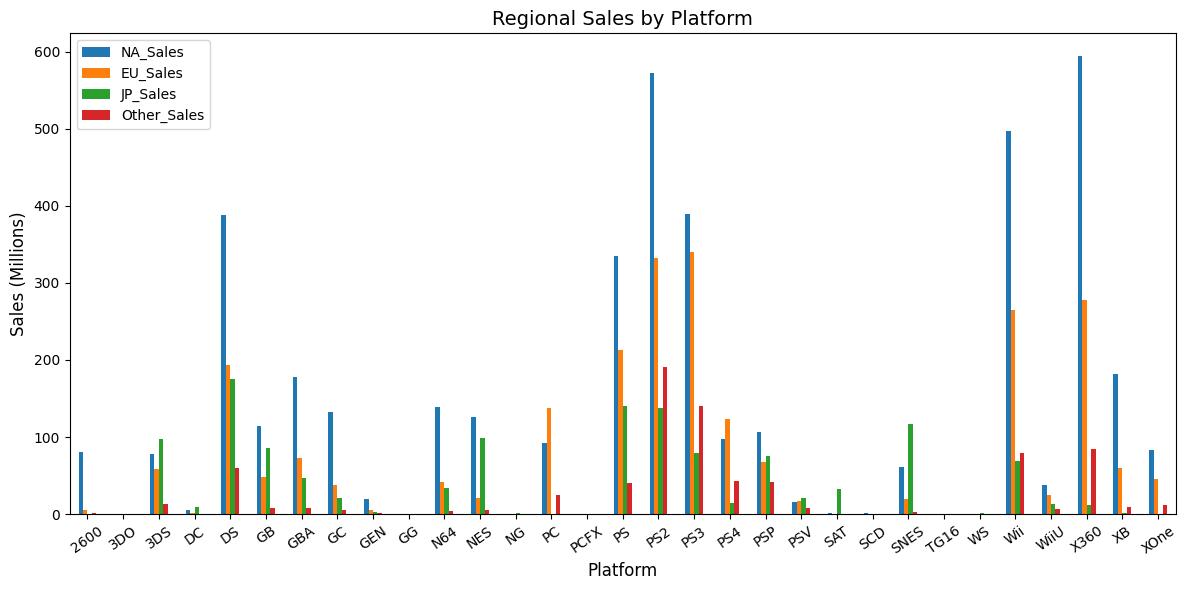

In [23]:
platform_sales = df_new.groupby('Platform')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()

platform_sales.plot(kind='bar', figsize=(12,6))
plt.title('Regional Sales by Platform', fontsize=14)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Sales (Millions)', fontsize=12)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

This grouped bar chart shows the sales of different gaming platforms across various regions. 
From the chart, we can see that platforms like X360, Wii, PS2, and DS perform strongly in the North American market, 
while other platforms have higher sales in Japan and other regions, 
indicating differences in platform preferences across regions.

### Key Information About the Data:
In the process of data cleaning, I conduct a data overview, understand the general content of the dataset, and observe the framework and missing values of the dataset. In this step, it was found that Year has 271 missing values, and Publisher has 58 missing values, and the Dtype the 'Year' column needs to be modified to integer. To ensure analytical integrity, these rows were dropped. Next, remove unnecessary spaces to avoid errors in the process of data analysis, and keep the capitalisation of the game for subsequent drawing. An Outlier was found in the subsequent cleaning process, the max of the Global_Sales field is 82.74, but because the Outliers of the game industry belongs to the popular game, which is a legitimate data point, removing it will affect the subsequent analysis, so it is retained. Finally, the cleaned dataset is re-stored as df_new, and the dataset is checked for duplicate values. No duplicate records were found, and the whole data cleaning process is over.

### Exploratory Data Analysis:
In the exploratory data analysis stage, it was found that the dataset contains 31 gaming platforms, 12 game genres, and 576 publishers. The DS platform has the highest number of game titles, Action games are the most popular. Because mean > median and the gap is large, the distribution is right-skewed, indicating that a few High-selling games pull the average up. Regional sales correlations show NA and EU markets are closely aligned, while JP differs. Yearly total sales indicate rapid market growth from 1995 to 2010, followed by a slight decline.

### Insights from Visualisations:
In order to visualise these discoveries and seek more insights, five visualisations were made. 

- The first line chart shows the change of game sales over the years, and 1995-2010 is the peak period of the game industry. The chart shows a sharp decline in sales in recent years, but this is actually due to the limitation Of the dataset, as data after 2016 is incomplete.
- The second bar chart shows the best-selling game types. Different types of games have different audiences, and more popular game types can usually get higher sales. For investors, action games are the least risky, while for game producers, the competition is the fiercest here.
- The third heatmap links all regional sales with global sales. The North American market accounts for the largest proportion of the global market, and the North American market share affects the success of a game. Due to different cultural differences, European and American game players have the same preferences, while Japanese players have unique tastes. For developers, facing the Japanese market requires a unique marketing strategy and in-depth localisation. 
- The long tail effect of the fourth scatter chart shows that the head game accounts for most of the sales, and the game industry is a Hit-driven industry. 
- It can be seen from the fifth composite bar chart that X360, Wii, PS2 and DS Dominate the market in the North American market, and different regions have different preferences for game platforms.

Total: 514 words